In [1]:
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr

#%matplotlib inline  
import matplotlib
import matplotlib.pyplot as plt

import hgrs.driver as driver
import hgrs

opj = os.path.join

hgrs.__version__

'1.0.6'

Set file paths, give path for L1C (L2C is normally in the same directory)


In [2]:
idir='/data/satellite/prisma/touria'

l1c_path = opj(idir,'PRS_L1_STD_OFFL_20220712063426_20220712063430_0001.he5')

l1c = os.path.basename(l1c_path)
l2c_path = l1c_path.replace('L1_STD_OFFL', 'L2C_STD')

In [3]:

dc_l1c = driver.read_L1C_data(l1c_path,reflectance_unit=True)
dc_l2c = driver.read_L2C_data(l2c_path)


Merge the two rasters (keep only parameters of interest from l2c)

In [ ]:
for param in ['sza', 'vza', 'raa']:
    dc_l1c[param] = dc_l2c[param]
del dc_l2c

In [4]:
dc_l1c

<xarray.Dataset> Size: 3GB
Dimensions:         (y: 1000, x: 1000, wl: 232)
Coordinates:
  * x               (x) int64 8kB 999 998 997 996 995 994 993 ... 6 5 4 3 2 1 0
  * y               (y) int64 8kB 999 998 997 996 995 994 993 ... 6 5 4 3 2 1 0
  * wl              (wl) float32 928B 407.0 415.8 423.8 ... 2.49e+03 2.497e+03
Data variables:
    Ltoa            (y, x, wl) float32 928MB 3.2 3.28 3.25 3.24 ... 0.08 0.0 0.0
    F0              (wl) float64 2kB 1.674e+03 1.768e+03 ... 51.69 51.55
    fwhm            (wl) float32 928B 11.35 10.38 9.751 ... 9.123 9.218 9.729
    lon             (y, x) float32 4MB 55.42 55.42 55.42 ... 55.08 55.08 55.08
    lat             (y, x) float32 4MB -21.03 -21.03 -21.03 ... -21.23 -21.23
    Rtoa            (y, x, wl) float64 2GB 0.0095 0.009219 0.009386 ... 0.0 0.0
    cloud_mask      (y, x) uint8 1MB 255 255 255 255 255 255 ... 0 0 0 0 0 255
    sunglint_mask   (y, x) uint8 1MB 255 255 255 255 255 255 ... 0 0 0 0 0 255
    landcover_mask  (y, x) uint8 1MB 255 255 255 255 255 255 ... 0 0 0 0 0 255
Attributes:
    description:       PRISMA L1C cube data
    L1C_product_name:  PRS_L1_STD_OFFL_20220712063426_20220712063430_0001.he5
    acquisition_date:  2022-07-12T06:34:26.543000
    sza:               50.781876
    saa:               33.61144

In [6]:
from hgrs import utils

output_dataset = utils.reproj().regridding(dc_l1c, output_grid_size=(1000, 1000), d_input_crs=4326)


/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xesmf/backend.py:41: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xesmf/smm.py:131: UserWarning: Input array is not C_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not C_CONTIGUOUS. ' 'Will affect performance.')
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/xesmf/smm.p

In [7]:
output_dataset.rio.reproject(dst_crs=3857)

<xarray.Dataset> Size: 3GB
Dimensions:         (x: 1003, y: 997, wl: 232)
Coordinates:
  * x               (x) float64 8kB 6.131e+06 6.131e+06 ... 6.17e+06 6.17e+06
  * y               (y) float64 8kB -2.388e+06 -2.388e+06 ... -2.426e+06
  * wl              (wl) float32 928B 407.0 415.8 423.8 ... 2.49e+03 2.497e+03
    spatial_ref     int64 8B 0
Data variables:
    Ltoa            (wl, y, x) float32 928MB nan nan nan nan ... nan nan nan nan
    Rtoa            (wl, y, x) float64 2GB nan nan nan nan ... nan nan nan nan
    cloud_mask      (y, x) uint8 1000kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    sunglint_mask   (y, x) uint8 1000kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    landcover_mask  (y, x) uint8 1000kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    fwhm            (wl) float32 928B 11.35 10.38 9.751 ... 9.123 9.218 9.729
    F0              (wl) float64 2kB 1.674e+03 1.768e+03 ... 51.69 51.55
Attributes:
    regrid_method:  bilinear

Merge the two rasters (keep only parameters of interest from l2c)

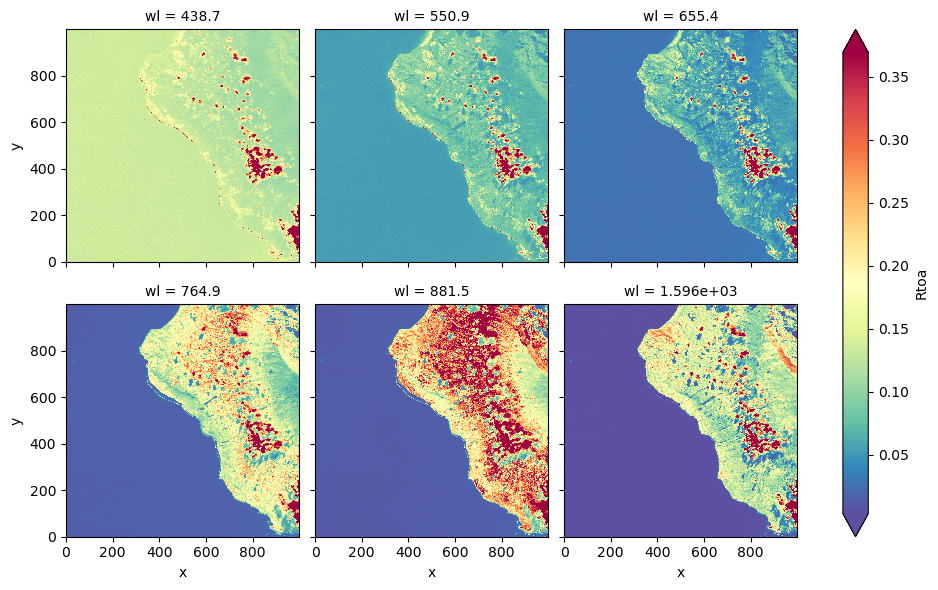

In [8]:
dc_l1c.Rtoa.sel(wl=[440,550,660,770,880,1600],method='nearest').plot.imshow(col='wl',col_wrap=3,cmap=plt.cm.Spectral_r,robust=True)

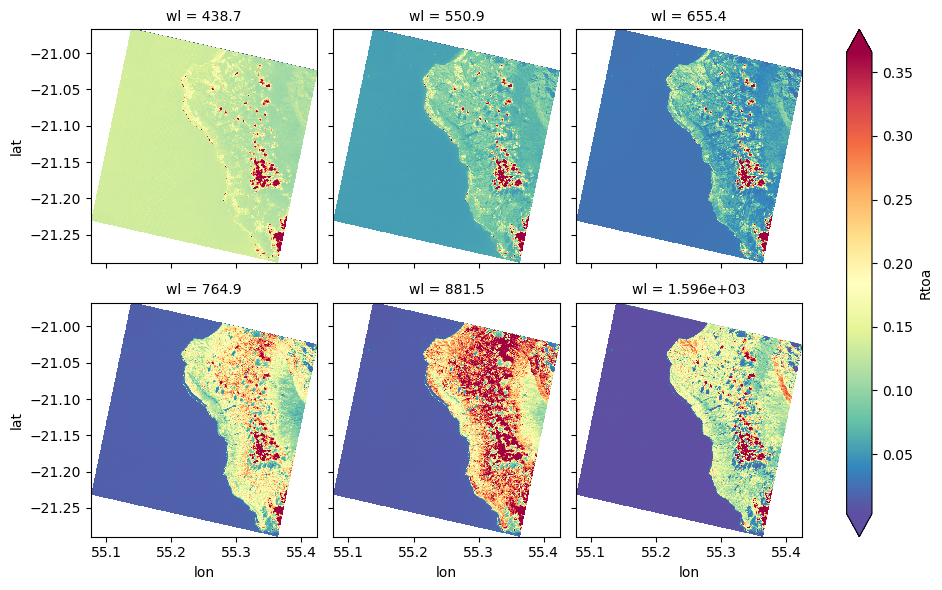

In [9]:
output_dataset.Rtoa.sel(wl=[440,550,660,770,880,1600],method='nearest').plot.imshow(col='wl',col_wrap=3,cmap=plt.cm.Spectral_r,robust=True)